<a href="https://colab.research.google.com/github/adithisd/data-science-projects-with-R/blob/main/NN_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

['Pen', 'Scissors', 'Book']
Classes: ['Book', 'Pen', 'Scissors']
Epoch 1
Train Loss: 3.8772
Val Loss: 1.2058
-------------------------
Epoch 2
Train Loss: 3.2536
Val Loss: 1.1167
-------------------------
Epoch 3
Train Loss: 3.1604
Val Loss: 1.1136
-------------------------
Epoch 4
Train Loss: 3.0053
Val Loss: 1.1806
-------------------------
Epoch 5
Train Loss: 2.7428
Val Loss: 1.1848
-------------------------
Epoch 6
Train Loss: 2.4051
Val Loss: 1.1364
-------------------------
Epoch 7
Train Loss: 1.9903
Val Loss: 1.1457
-------------------------
Epoch 8
Train Loss: 1.5800
Val Loss: 1.1139
-------------------------
Epoch 9
Train Loss: 1.2209
Val Loss: 1.1353
-------------------------
Epoch 10
Train Loss: 0.9238
Val Loss: 1.1887
-------------------------


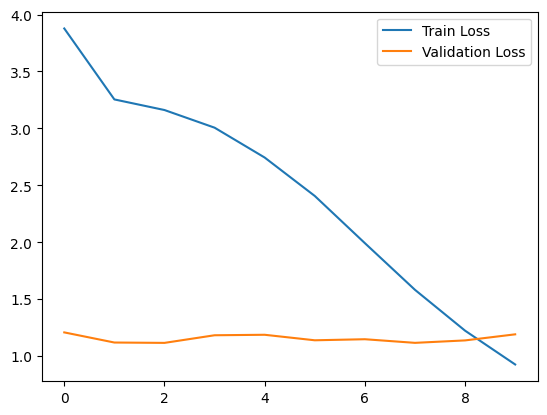

In [ ]:
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import matplotlib.pyplot as plt

!unzip -q dataset.zip
import os
print(os.listdir('dataset'))

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(root='dataset', transform=transform)
print("Classes:", dataset.classes)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 30 * 30, 64),
            nn.ReLU(),
            nn.Linear(64, 3)
        )
    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

model = SimpleCNN()

# THESE WERE MISSING:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses = []
val_losses = []

for epoch in range(10):
    model.train()
    total_train_loss = 0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
    train_losses.append(total_train_loss)

    # Validation
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_val_loss += loss.item()
    val_losses.append(total_val_loss)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {total_train_loss:.4f}")
    print(f"Val Loss: {total_val_loss:.4f}")
    print("-------------------------")

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.show()